In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# Normalization를 위한 mean, std 값 구하기

_dataset = datasets.ImageFolder(root='./datasets/cifar10/train', transform=transforms.ToTensor())
_loader  = DataLoader(_dataset)

mean   = torch.zeros(3)
sq_mean = torch.zeros(3)
n_pixels = 0

with torch.no_grad():
    for images, _ in _loader:
        b, c, h, w = images.shape
        n_pixels += b * h * w
        mean     += images.sum(dim=[0, 2, 3])
        sq_mean  += (images ** 2).sum(dim=[0, 2, 3])

mean  /= n_pixels
std    = (sq_mean / n_pixels - mean ** 2).sqrt()

mean, std

(tensor([0.4914, 0.4822, 0.4465]), tensor([0.2470, 0.2435, 0.2616]))

In [ ]:
# CIFAR-10 channel-wise(R, G, B) mean/std
MEAN = tuple(round(float(i), 4) for i in mean)
STD  = tuple(round(float(i), 4) for i in std)

train_transform = transforms.Compose([
    # Data Augmentation: 학습 데이터를 인위적으로 변경하여 다양성을 높인다.

    # 상하좌우 4px zero-padding 후 32×32 랜덤 크롭, 물체 위치가 조금씩 달라진다.
    transforms.RandomCrop(32, padding=4),

    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),
    
    # 밝기 및 대비 ±20% 랜덤 변화
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # PIL Image, Numpy array -> PyTorch Tensor
    transforms.ToTensor(),
    
    # 채널별 정규화: (pixel - mean) / std
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [5]:
# ImageFolder로 train, test 폴더 내부 class 폴더 자동 인식
train_dataset = datasets.ImageFolder(root='./datasets/cifar10/train', transform=train_transform)
test_dataset  = datasets.ImageFolder(root='./datasets/cifar10/test',  transform=test_transform)

# DataLoader로 dataset을 mini-batch 단위로 묶어서 제공
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(train_dataset.classes)
print(train_dataset.class_to_idx)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [6]:
print(len(train_dataset))
print(len(test_dataset))

50000
10000


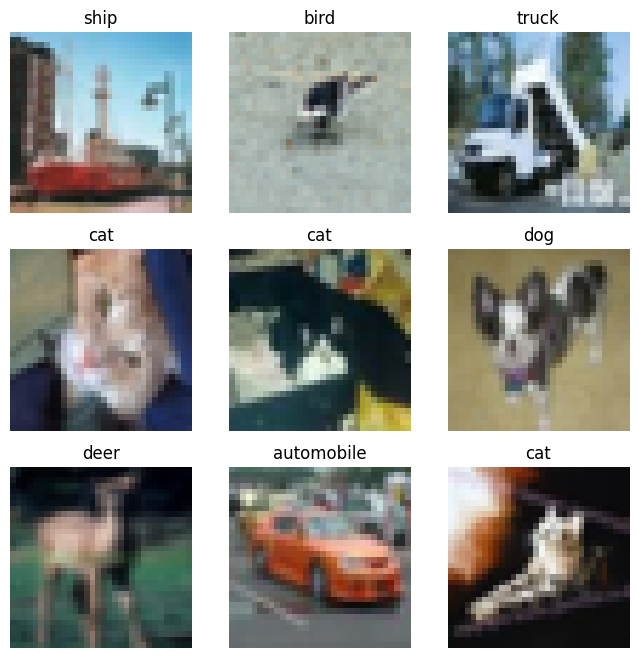

In [7]:
labels = {
  0: 'airplane',
  1: 'automobile',
  2: 'bird',
  3: 'cat',
  4: 'deer',
  5: 'dog',
  6: 'frog',
  7: 'horse',
  8: 'ship',
  9: 'truck'
}

pre = datasets.ImageFolder(root='./datasets/cifar10/train', transform=transforms.ToTensor())

figure = plt.figure(figsize=(8, 8))
for i in range(1, 10):
  idx = torch.randint(len(pre), size=(1, )).item()
  img, label = pre[idx]
  figure.add_subplot(3, 3, i)
  plt.title(labels[label])
  plt.axis('off')
  plt.imshow(img.permute(1, 2, 0))

plt.show()

nn.Conv2d(in_channels, out_channels, kernel_size, padding, stride)
* input_channels: 시작은 이미지 channel 수(grayscale=1, RGB=3), 다음은 이전 layer의 out_channels와 동일
* output_channels: 일반적으로 32, 64시작, 32 -> 64 -> 128 -> 256으로 2배씩 증가 (깊어질수록 복잡한 feature가 많아지므로)
* kernel_size: 일반적으로 3 (3x3)
* padding: kernel_size=3 이라면 padding=1
* stride: 일반적으로 1, size 줄이려면 2

nn.BatchNorm2d(num_features)
* num_features: 이전 layer의 output_channels와 동일

nn.MaxPool2d(kernel_size)
* kernel_size: 일반적으로 2 (spatial size를 절반으로 줄이기 위함)

nn.Linear(in_features, out_features)
* in_features: 이전 layer의 out_features와 동일, GAP 사용 시 마지막 Conv2d의 out_channels
* out_features: 점진적으로 1/2로 감소, 마지막 Linear는 class 수

In [8]:
# CNN 학습 class 정의
# Convolution layer + MaxPooling -> Fully-Connected Layer

class CNN(nn.Module):  # nn.Module: PyTorch 신경망 모듈 base class 상속
    def __init__(self):
        super().__init__()  # nn.Module 생성자 호출
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), 
            nn.ReLU(inplace=True),
            
            nn.Conv2d(64, 64, 3, padding=1, bias=False),  # 이전 feature map에서 동일한 channel size로 더 자세한 패턴 학습
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32×32 → 16×16

            # Layer 2
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16×16 → 8×8

            # Layer 3
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 8×8 → 4×4
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),  # training 중 무작위로 50%의 뉴런 비활성화, 과적합 방지를 위한 정규화 기법
            nn.Linear(256, 10)
        )

    def forward(self, x):  # nn.Module forward() overriding
        return self.classifier(self.features(x))

model = CNN().to(device)

In [9]:
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss function
optimizer = optim.Adam(model.parameters(), lr=0.0007)  # Adam optimizer, learning rate: 0.0007

In [10]:
train_losses, test_losses         = [], []
train_accuracies, test_accuracies = [], []

In [11]:
epochs = 20

for epoch in range(epochs):

    # ── Train ──
    model.train()  # 모델 학습 진행
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()  # loss값을 통해 현재 기울기를 계산하여 파라미터 값을 .grad에 저장
        optimizer.step() # .grad 값을 기반으로 최적의 파라미터 계산 후 가중치 업데이트
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ── Test ──
    model.eval()  # 모델 추론 진행
    correct_test, total_test, test_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc = 100 * correct_test / total_test

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Test Loss: {test_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/20] Train Loss: 1.4208 | Test Loss: 1.1383 | Train Acc: 47.26% | Test Acc: 59.83%
Epoch [2/20] Train Loss: 0.9904 | Test Loss: 0.9309 | Train Acc: 64.93% | Test Acc: 67.03%
Epoch [3/20] Train Loss: 0.8111 | Test Loss: 0.7249 | Train Acc: 71.86% | Test Acc: 74.23%
Epoch [4/20] Train Loss: 0.6992 | Test Loss: 0.7593 | Train Acc: 76.00% | Test Acc: 75.17%
Epoch [5/20] Train Loss: 0.6209 | Test Loss: 0.7267 | Train Acc: 78.98% | Test Acc: 76.13%
Epoch [6/20] Train Loss: 0.5670 | Test Loss: 0.5851 | Train Acc: 80.86% | Test Acc: 79.94%
Epoch [7/20] Train Loss: 0.5237 | Test Loss: 0.5771 | Train Acc: 82.34% | Test Acc: 80.94%
Epoch [8/20] Train Loss: 0.4858 | Test Loss: 0.5382 | Train Acc: 83.63% | Test Acc: 82.04%
Epoch [9/20] Train Loss: 0.4513 | Test Loss: 0.4448 | Train Acc: 84.74% | Test Acc: 85.04%
Epoch [10/20] Train Loss: 0.4269 | Test Loss: 0.4613 | Train Acc: 85.72% | Test Acc: 84.50%
Epoch [11/20] Train Loss: 0.4020 | Test Loss: 0.5018 | Train Acc: 86.45% | Test Acc: 83.2

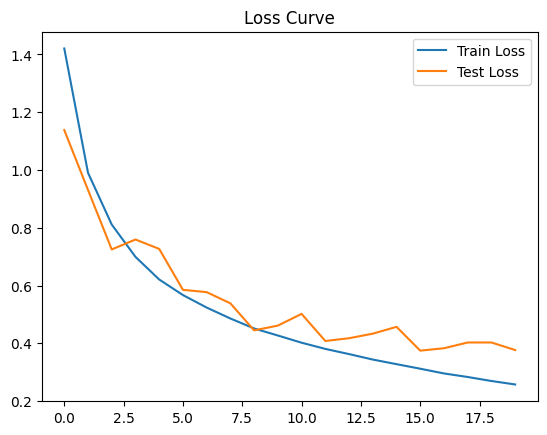

In [12]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

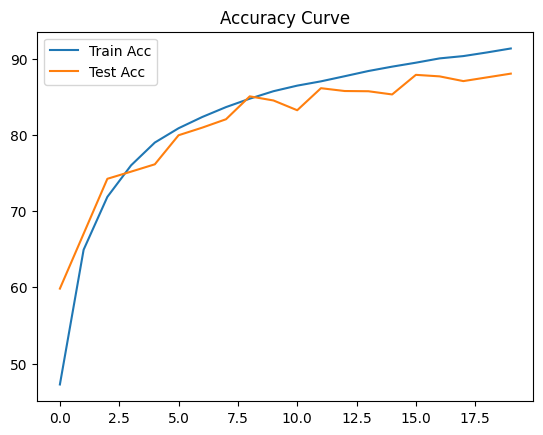

In [13]:
plt.figure()
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

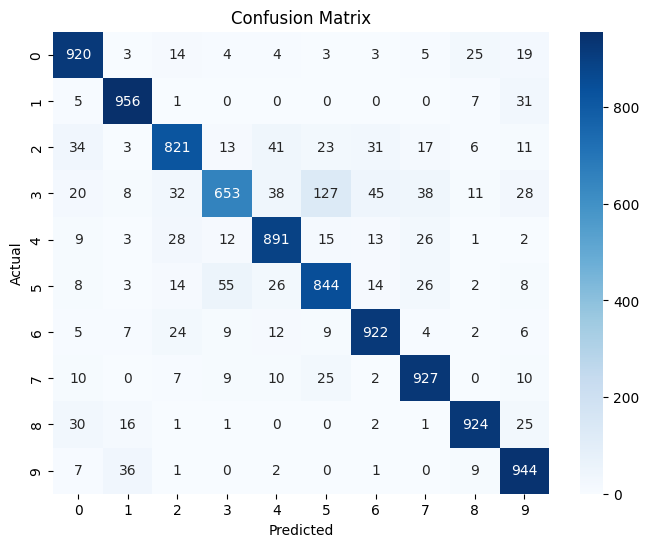

In [14]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

 
cm = confusion_matrix(all_labels, all_preds)

# 🔹 Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

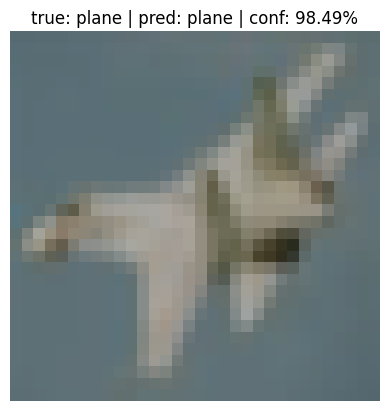

In [15]:
CLASSES = ("plane","car","bird","cat","deer","dog","frog","horse","ship","truck")
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
STD  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)

images, labels = next(iter(test_loader))

idx = 1
single_image = images[idx].unsqueeze(0)
true_label   = labels[idx].item()

with torch.no_grad():
    output      = model(single_image.to(device))
    probs       = torch.softmax(output, dim=1)
    pred_label  = torch.argmax(probs, dim=1).item()
    confidence  = probs[0][pred_label].item()

# 역정규화(denormalize): Normalize 적용 전 원본 픽셀값으로 복원
img = images[idx] * STD + MEAN
img = img.permute(1, 2, 0).clamp(0, 1)  # clamp: 역정규화 후 범위를 [0,1]로 보정

plt.imshow(img)
plt.title(f"true: {CLASSES[true_label]} | pred: {CLASSES[pred_label]} | conf: {confidence:.2%}")
plt.axis('off')
plt.show()